In [1]:
'''
Code to generate Figure 1: Context-aware PGS cutoff points for atrial fibrillation in the UK Biobank
'''

import pandas as pd
import numpy as np
import random

from options.options import Options
import util.util as util
import util.pre_process as pre

from sklearn.linear_model import LinearRegression, LogisticRegression

import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
import numpy as np

from scipy.stats import norm

phen_label = 'AFIB'
    
opt = Options()
opt.initialize()

emerge_cutoff = opt.phen_params[phen_label]['emerge_cut']
pgs_emerge_cutoff = norm.ppf(1-emerge_cutoff)

pgs_df = pd.read_csv(opt.prs_file, delim_whitespace=True, index_col='IID')
covars_df = pd.read_csv(opt.env_file, sep='\t', index_col='IID')

pc_cols = ['chip']+[df_col for df_col in covars_df.columns if df_col.startswith('PC')]
pcs_df = covars_df[pc_cols].iloc[:, :11]
covars_df = covars_df[opt.covars]

phen = pgs_df[opt.phen_params[phen_label]['phen']]
phen = phen.dropna()
pgs = pgs_df[opt.phen_params[phen_label]['pgs']].loc[phen.index]
pgs = (pgs-pgs.mean())/pgs.std()
if opt.phen_params[phen_label]['pgs_flip']:
    pgs = -1*pgs
covars_df = covars_df.loc[phen.index]

covars_imputed_df = pre.impute_covars(covars_df)
covars_imputed_df, _, _ = pre.standardize_covars(covars_imputed_df)
covars = pd.concat([covars_imputed_df, pcs_df], axis=1)
covars = covars.loc[pgs.index]

bin_defs = opt.bin_defs
bounds, labels, label_map = util.create_bins_and_indices(covars_df, bin_defs)

util.create_folder(f'results/{phen_label}')

print('\n')
print(f'Total: {len(phen)}')
for sex_label in ['Female', 'Male']:
    n_sex = len(phen.loc[label_map['Sex: '+sex_label]])
    n_cases = phen.loc[label_map['Sex: '+sex_label]].sum()
    print(f'{sex_label} Cases: {n_cases}/{n_sex}')

for k in label_map.keys():
    print(len(label_map[k]), ': ', k,)

rng = np.random.default_rng(np.random.PCG64(42))

N Missing Data
Sex                               0
Age                               0
Household_Income              52137
Alcohol_Intake                  510
Townsend_Deprivation_Index      447
Current_Smoking                1571
dtype: int64


Total: 375054
Female Cases: 5587/202280
Male Cases: 11334/172774
202280 :  Sex: Female
172774 :  Sex: Male
84265 :  Age: 40-49
124510 :  Age: 50-59
166277 :  Age: 60-inf
64625 :  Alcohol_Intake: <1 per month
139652 :  Alcohol_Intake: 1-8 per month
170267 :  Alcohol_Intake: >12 per month
201738 :  Current_Smoking: Never
171745 :  Current_Smoking: Current or Prior
70175 :  Household_Income: <18k
167090 :  Household_Income: 18k to 52k
85652 :  Household_Income: >52k
141325 :  Townsend_Deprivation_Index: -inf--3
133498 :  Townsend_Deprivation_Index: -3-0
99784 :  Townsend_Deprivation_Index: 0-inf


In [4]:
# Functions to find context-aware PGS cut points

def odds_ratio(pgs, phen, pgs_cut):
    high_risk = pgs >= pgs_cut
    odds_high = (phen[high_risk].sum() / (len(phen[high_risk]) - phen[high_risk].sum()))
    odds_low = (phen[~high_risk].sum() / (len(phen[~high_risk]) - phen[~high_risk].sum()))
    
    return odds_high / odds_low

def find_pgs_cut(pgs, phen, baseline_or, starting_point, learning_rate=1e-4, thresh=0.001, max_iter=100000):
    pgs_cut = starting_point
    prev_error = float('inf')
    
    for _ in range(max_iter):
        current_or = odds_ratio(pgs, phen, pgs_cut)
        error = abs(current_or - baseline_or)

        if error < thresh:
            return pgs_cut

        # Stop if gradient increases
        #if error > prev_error:
        #    return pgs_cut

        prev_error = error
        gradient = np.sign(current_or - baseline_or)
        pgs_cut -= learning_rate * gradient

    print('Max Iter Reached')

    return pgs_cut

In [5]:
# Baseline OR
pgs_ = pgs.values
phen_ = phen.values
all_or = odds_ratio(pgs_, phen_, pgs_emerge_cutoff)

results = {}
results['All'] = {'OR': all_or, 'CUT': pgs_emerge_cutoff, 'CUT (%)': 100*emerge_cutoff, 'Adj. OR': all_or}

print('PGS CUT:', pgs_emerge_cutoff)
print('PGS OR:', all_or)

PGS CUT: 1.8807936081512509
PGS OR: 3.305139731812479


In [9]:
# Calculate OR for subgroups

idx_dict = {'40-49': label_map['Age: 40-49'], 
            '40-49; F': np.intersect1d(label_map['Sex: Female'], label_map['Age: 40-49']),
            '40-49; M': np.intersect1d(label_map['Sex: Male'], label_map['Age: 40-49']),
            '40-49; F; NS': np.intersect1d(np.intersect1d(label_map['Sex: Female'], label_map['Age: 40-49']), label_map['Current_Smoking: Never']),
            '40-49; M; NS': np.intersect1d(np.intersect1d(label_map['Sex: Male'], label_map['Age: 40-49']), label_map['Current_Smoking: Never'])}

for label in idx_dict.keys():
    print('Doing:', label)
    idx_org = idx_dict[label]
    pgs_, phen_ = pgs.loc[idx_org].values, phen.loc[idx_org].values

    base_or = odds_ratio(pgs_, phen_, pgs_emerge_cutoff)
    pgs_cut = find_pgs_cut(pgs_, phen_, all_or, pgs_emerge_cutoff)
    adj_or_value = odds_ratio(pgs_, phen_, pgs_cut)
    per_cut = (1 - norm.cdf(pgs_cut)) * 100

    results[label] = {'OR': base_or, 'CUT': pgs_cut, 'CUT (%)': per_cut, 'Adj. OR': adj_or_value}

df_results = pd.DataFrame.from_dict(results, orient='index')

Doing: 40-49
Doing: 40-49; F
Doing: 40-49; M
Doing: 40-49; F; NS
Max Iter Reached
Doing: 40-49; M; NS


In [8]:
df_results.round(2)

,OR,CUT,CUT (%),Adj. OR
All,3.31,1.88,3.00,3.31
40-49,4.31,1.53,6.26,3.31
40-49; F,3.11,1.96,2.52,3.30
40-49; M,4.88,1.23,10.99,3.31
40-49; F; NS,4.26,1.76,3.94,3.31
40-49; M; NS,6.17,1.03,15.11,3.31


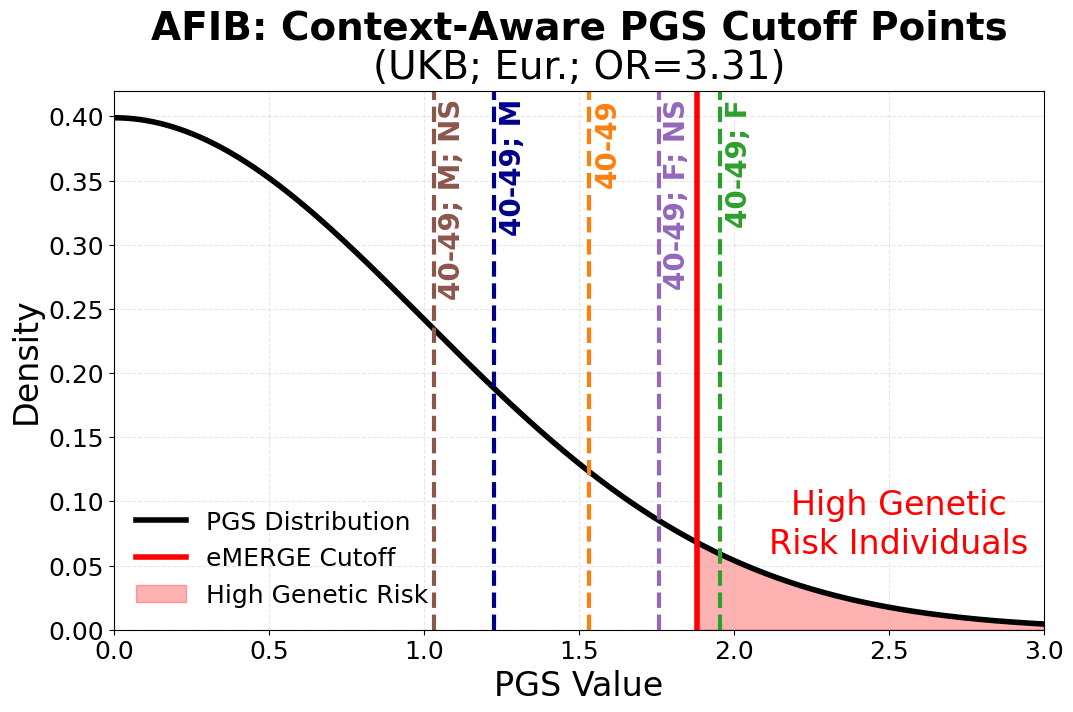

In [10]:
# Figure generation

import scipy.stats as stats

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "darkblue", "#9467bd", "#8c564b"]

# Generate normal distribution for 0 ≤ x ≤ 3
x = np.linspace(0, 3, 1000)
y = stats.norm.pdf(x, 0, 1)  # Standard normal distribution

# Define the cutoff for shading
cut_values = df_results["CUT"].to_dict()

# Create plot
plt.figure(figsize=(12, 7))

# Plot normal distribution
plt.plot(x, y, label="PGS Distribution", color="black", linewidth=4)

# Highlight the main cutoff line
plt.axvline(x=cut_values['All'], color='red', linestyle="-", linewidth=4, label='eMERGE Cutoff')

# Shade the area greater than CUT: All
x_shade = np.linspace(cut_values['All'], 3, 500)
y_shade = stats.norm.pdf(x_shade, 0, 1)
plt.fill_between(x_shade, y_shade, color='red', alpha=0.3, label="High Genetic Risk")

# Add vertical lines for CUT values with annotations
for (label, cut), color in zip(cut_values.items(), colors):
    if label == 'All':
        continue
    plt.axvline(x=cut, color=color, linestyle="--", linewidth=3)
    plt.text(cut+.015, max(y)+.015, f"{label}", rotation=90, verticalalignment="top", fontweight='bold', fontsize=20, color=color)

# Add text annotation for high genetic risk
plt.text(
    cut_values['All'] + 0.65, max(y) * 0.15, 
    "High Genetic\nRisk Individuals", fontsize=24, color="red", ha="center"
)

# Labels, title, and legend
plt.xlabel("PGS Value", fontsize=24)
plt.ylabel("Density", fontsize=24)

# Add the second non-bold title
plt.text(1.5, 0.46, "AFIB: Context-Aware PGS Cutoff Points", fontsize=28, ha="center", fontweight='bold')
plt.text(1.5, 0.43, "(UKB; Eur.; OR=3.31)", fontsize=28, ha="center")

plt.legend(frameon=False, fontsize=18, loc='lower left')

plt.ylim((0,.42))
plt.xlim((0,3))

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Improve grid and layout
plt.grid(alpha=0.3, linestyle="--")

# Show plot
plt.savefig('results/context_aware_cutoffs.png', bbox_inches='tight')
plt.show()